## file_path, W_um/L_um, Cox_total_F update

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress

# Device parameters: change these values and all Vth / SS / mobility results update together
W_um = 40
L_um = 20
W_over_L = W_um / L_um
L_m = L_um * 1e-6
W_m = W_um * 1e-6

# Gate capacitance for this device. Update if a different device is measured.
Cox_total_F = 4.25e-12

file_path = '260206_I_V Sweep - Unit (transfer) [260206_ALD_IGZO_#6_WL_1010_R02_lower_TR_2nd(2) ; 2_6_2026 1_54_35 PM].csv'
with open(file_path, 'r', encoding='utf-8') as f:
    lines = f.readlines()

for i, line in enumerate(lines):
    if any(col.strip().startswith('DataValue') for col in line.split(',')):
        header_row = i - 2
        break
df = pd.read_csv(file_path, sep=',', header=header_row)

df = df.iloc[:, 1:]
df.columns = df.columns.str.strip()

df.head(10)


,VG,VD,VS,IG,ID,IS,SS
0,-3.00,0.1,0,1.210000e-13,-2.900000e-14,-7.100000e-14,72.960843643274529
1,-2.94,0.1,0,2.200000e-14,-6.600000e-14,-1.300000e-14,-76.164538622412621
2,-2.88,0.1,0,-1.030000e-13,6.000000e-15,-2.100000e-14,-432.22724271481877
3,-2.82,0.1,0,2.600000e-14,-5.000000e-14,-4.200000e-14,58.913576871567443
4,-2.76,0.1,0,5.200000e-14,-4.600000e-14,-5.800000e-14,-288.797929761355
5,-2.70,0.1,0,-5.000000e-14,-3.300000e-14,-5.600000e-14,-43.955575292667824
6,-2.64,0.1,0,-1.700000e-14,3.000000e-15,-6.000000e-15,-180.915190951796
7,-2.58,0.1,0,-3.800000e-14,-1.700000e-14,-3.700000e-14,141.62670013725884
8,-2.52,0.1,0,1.560000e-13,7.000000e-15,-4.000000e-14,-618.05965859735215
9,-2.46,0.1,0,5.500000e-14,-1.400000e-14,-4.500000e-14,74.560192147153685


## data 제대로 들어왔는지 확인

In [24]:
df['ID'] = df['ID'].abs()
df['ID'] = np.clip(df['ID'], 1e-16, None)

df.value_counts()
df.describe()
row_counts = df.shape[0]

for i in df.columns:
    empty = df[i].isna().sum()
    print(f'{i} column에서 빈값은 {empty}개임.')

VG column에서 빈값은 0개임.
VD column에서 빈값은 0개임.
VS column에서 빈값은 0개임.
IG column에서 빈값은 0개임.
ID column에서 빈값은 0개임.
IS column에서 빈값은 0개임.
SS column에서 빈값은 0개임.


## graph plot

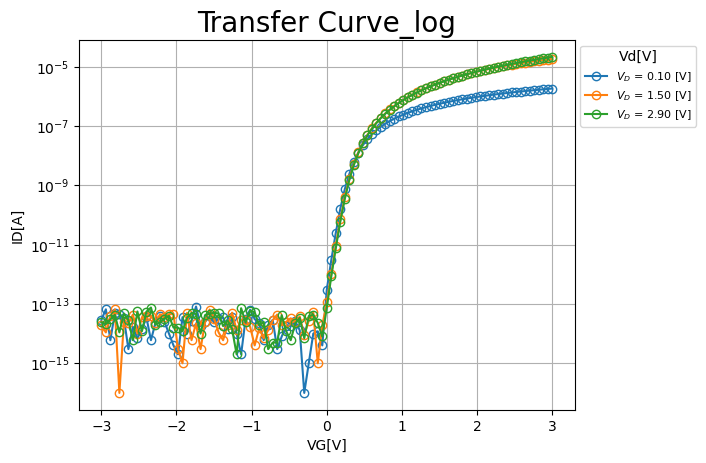

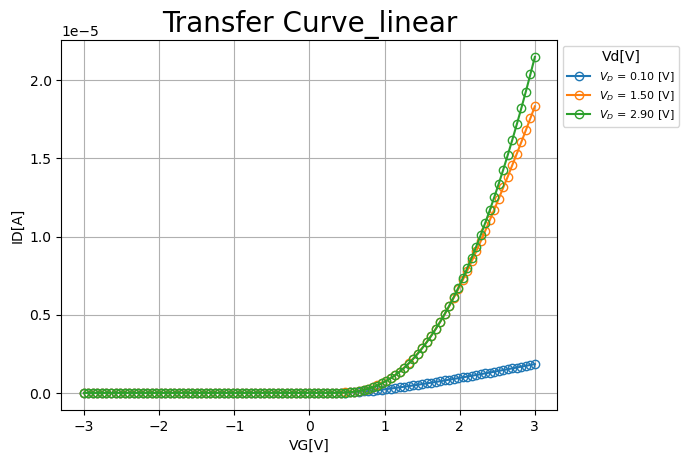

In [25]:
fig, ax  = plt.subplots()
for VD, g in df.groupby('VD'):
    plt.semilogy(g['VG'], g['ID'],marker='o',markerfacecolor='none',label=fr'$V_D$ = {VD:.2f} [V]')

ax.set_xlabel('VG[V]')
ax.set_ylabel('ID[A]')
ax.set_title('Transfer Curve_log', fontsize = 20)
ax.legend(title = 'Vd[V]',bbox_to_anchor = (1,1),loc = 'upper left',fontsize = 8)
ax.grid(True)

fig, ax  = plt.subplots()
for VD, g in df.groupby('VD'):
    plt.plot(g['VG'], g['ID'],marker='o',markerfacecolor='none',label=fr'$V_D$ = {VD:.2f} [V]')

ax.set_xlabel('VG[V]')
ax.set_ylabel('ID[A]')
ax.set_title('Transfer Curve_linear', fontsize = 20)
ax.legend(title = 'Vd[V]',bbox_to_anchor = (1,1),loc = 'upper left',fontsize = 8)
ax.grid(True)



## get vth, ss

In [26]:
target1 = -10  # log10(|ID|/(W/L)) = -10 -> Vth
target2 = -9   # log10(|ID|/(W/L)) = -9  -> SS upper decade

vth_by_vd_10 = {}
vth_by_vd_9 = {}
ss_by_vd = {}

for vd, g in df.groupby('VD'):
    g = g.sort_values('ID')

    VG = g['VG'].to_numpy(dtype=float)
    ID = g['ID'].to_numpy(dtype=float)

    absID = np.clip(np.abs(ID), 1e-300, None)
    normID = absID / W_over_L
    logI = np.log10(normID)

    diff1 = logI - target1
    diff2 = logI - target2
    cross_idx_10 = np.where(diff1[:-1] * diff1[1:] <= 0)[0]
    cross_idx_9 = np.where(diff2[:-1] * diff2[1:] <= 0)[0]

    if len(cross_idx_10) == 0:
        vth_by_vd_10[vd] = np.nan
        vth_by_vd_9[vd] = np.nan
        ss_by_vd[vd] = np.nan
        continue

    i1 = cross_idx_10[0]
    x0, x1 = VG[i1], VG[i1 + 1]
    y0, y1 = logI[i1], logI[i1 + 1]

    if y1 == y0:
        vth_10 = np.nan
    else:
        vth_10 = x0 + (target1 - y0) * (x1 - x0) / (y1 - y0)

    vth_by_vd_10[vd] = vth_10

    if len(cross_idx_9) == 0:
        vth_by_vd_9[vd] = np.nan
        ss_by_vd[vd] = np.nan
        continue

    i2 = cross_idx_9[0]
    z0, z1 = VG[i2], VG[i2 + 1]
    t0, t1 = logI[i2], logI[i2 + 1]

    if t1 == t0:
        vth_9 = np.nan
    else:
        vth_9 = z0 + (target2 - t0) * (z1 - z0) / (t1 - t0)

    vth_by_vd_9[vd] = vth_9

    if np.isnan(vth_10) or np.isnan(vth_9):
        ss_by_vd[vd] = np.nan
    else:
        ss_by_vd[vd] = ((vth_9 - vth_10) / (target2 - target1)) * 1000

print(f'W/L = {W_um:.1f} um / {L_um:.1f} um = {W_over_L:.2f}')
print(f'Vth criterion: log10(|ID|/(W/L)) = {target1}')
for vd in sorted(vth_by_vd_10.keys()):
    print(f'VD={vd}: Vth={vth_by_vd_10[vd]:.6f} V, SS={ss_by_vd[vd]:.3f} mV/dec')

summary_df = pd.DataFrame({
    'VD[V]': sorted(vth_by_vd_10.keys()),
    'Vth_normID=1e-10[V]': [vth_by_vd_10[vd] for vd in sorted(vth_by_vd_10.keys())],
    'SS[mV/dec]': [ss_by_vd[vd] for vd in sorted(ss_by_vd.keys())],
})
summary_df


W/L = 40.0 um / 20.0 um = 2.00
Vth criterion: log10(|ID|/(W/L)) = -10
VD=0.1: Vth=0.187905 V, SS=102.058 mV/dec
VD=1.5: Vth=0.215480 V, SS=93.347 mV/dec
VD=2.9: Vth=0.220500 V, SS=93.386 mV/dec


,VD[V],Vth_normID=1e-10[V],SS[mV/dec]
0,0.1,0.187905,102.058157
1,1.5,0.215480,93.346552
2,2.9,0.220500,93.385602


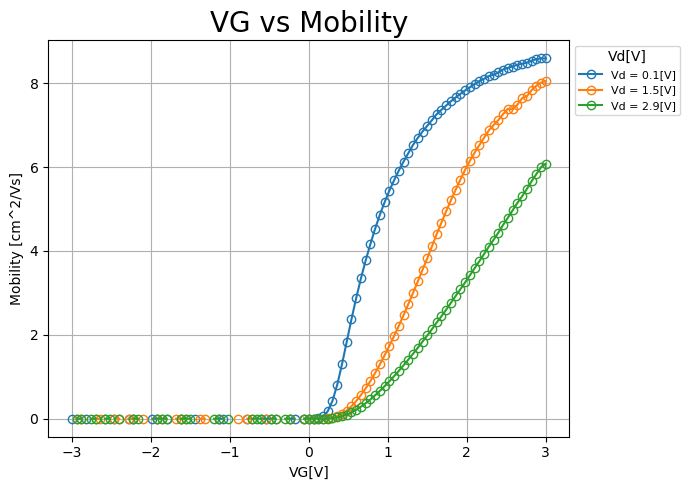

In [27]:
# VG vs mobility plot
mobility_curve_rows = []

fig, ax = plt.subplots(figsize=(7, 5))
for vd, g in df.groupby('VD'):
    g = g.sort_values('VG').copy()
    vg = g['VG'].to_numpy(dtype=float)
    idrain = g['ID'].to_numpy(dtype=float)

    gm = np.gradient(idrain, vg)
    if vd == 0:
        mu_cm2_vs = np.full_like(gm, np.nan, dtype=float)
    else:
        mu_m2_vs = gm * (L_m ** 2) / (Cox_total_F * abs(vd))
        mu_cm2_vs = mu_m2_vs * 1e4

    plot_mu = np.where(mu_cm2_vs > 0, mu_cm2_vs, np.nan)
    ax.plot(vg, plot_mu, marker='o', markerfacecolor='none', label=f'Vd = {vd}[V]')

    temp_df = pd.DataFrame({
        'VG[V]': vg,
        'VD[V]': vd,
        'gm[A/V]': gm,
        'mobility[cm^2/Vs]': mu_cm2_vs,
    })
    mobility_curve_rows.append(temp_df)

ax.set_xlabel('VG[V]')
ax.set_ylabel('Mobility [cm^2/Vs]')
ax.set_title('VG vs Mobility', fontsize=20)
ax.legend(title='Vd[V]', bbox_to_anchor=(1, 1), loc='upper left', fontsize=8)
ax.grid(True)
plt.tight_layout()
plt.show()


In [28]:
mobility_curve_df = pd.concat(mobility_curve_rows, ignore_index=True)
mobility_curve_df.head(20)


,VG[V],VD[V],gm[A/V],mobility[cm^2/Vs]
0,-3.00,0.1,6.166667e-13,5.803922e-06
1,-2.94,0.1,-1.916667e-13,-1.803922e-06
2,-2.88,0.1,-1.333333e-13,-1.254902e-06
3,-2.82,0.1,3.333333e-13,3.137255e-06
4,-2.76,0.1,-1.416667e-13,-1.333333e-06
5,-2.70,0.1,-3.583333e-13,-3.372549e-06
6,-2.64,0.1,-1.333333e-13,-1.254902e-06
7,-2.58,0.1,3.333333e-14,3.137255e-07
8,-2.52,0.1,-2.500000e-14,-2.352941e-07
9,-2.46,0.1,2.333333e-13,2.196078e-06


In [29]:
mobility_summary_rows = []
for vd, g in mobility_curve_df.groupby('VD[V]'):
    positive_mu = g.loc[g['mobility[cm^2/Vs]'] > 0, 'mobility[cm^2/Vs]']
    mobility_summary_rows.append({
        'VD[V]': vd,
        'Vth_normID=1e-10[V]': vth_by_vd_10.get(vd, np.nan),
        'SS[mV/dec]': ss_by_vd.get(vd, np.nan),
        'mu_max[cm^2/Vs]': positive_mu.max() if len(positive_mu) else np.nan,
        'mu_mean_positive[cm^2/Vs]': positive_mu.mean() if len(positive_mu) else np.nan,
    })

mobility_summary_df = pd.DataFrame(mobility_summary_rows).sort_values('VD[V]').reset_index(drop=True)
mobility_summary_df


,VD[V],Vth_normID=1e-10[V],SS[mV/dec],mu_max[cm^2/Vs],mu_mean_positive[cm^2/Vs]
0,0.1,0.187905,102.058157,8.590588,4.135996
1,1.5,0.215480,93.346552,8.049150,2.610538
2,2.9,0.220500,93.385602,6.078161,1.549755


## Saturation Region Mobility  (√|Id| vs Vg 방법)

**원리**: saturation 영역에서 $I_D = \frac{\mu_{sat} C_{ox} W}{2L}(V_{GS}-V_{th})^2$  
→ $\sqrt{|I_D|}$ vs $V_G$ 직선 fit의 기울기 $k$로부터:

$$\mu_{sat} = k^2 \cdot \frac{2L^2}{C_{ox,total}}$$

Fit 구간: $\frac{d\sqrt{|I_D|}}{dV_G}$ 가 최대값의 50 % 이상인 구간 (steepest turn-on region)

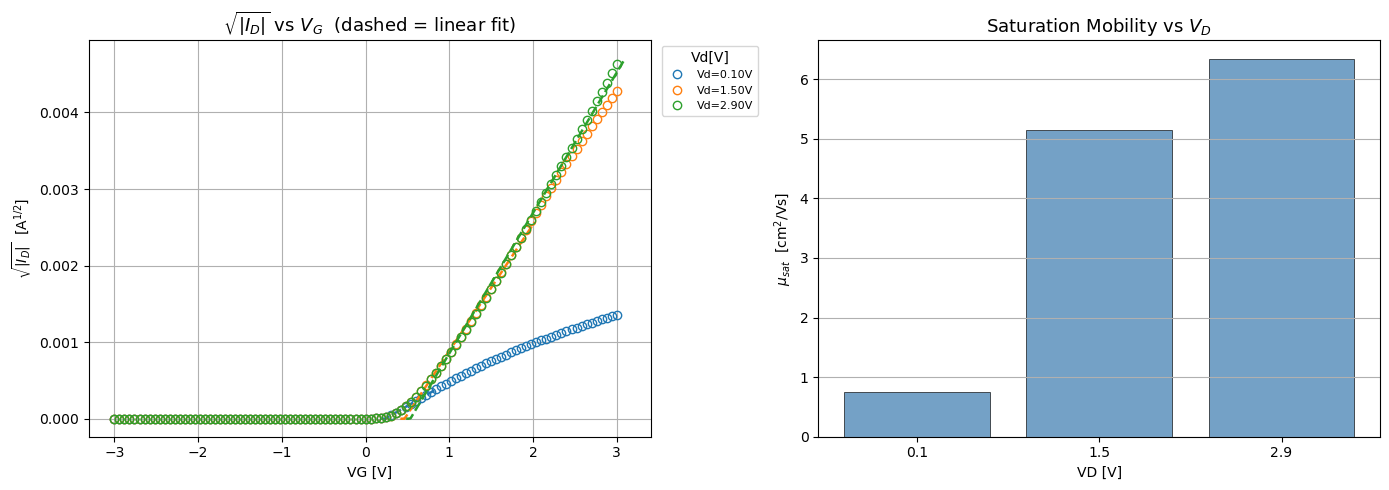

In [30]:
sat_rows = []

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax_sqrt, ax_mu = axes
colors = plt.cm.tab10.colors

for idx, (vd, g) in enumerate(df.groupby('VD')):
    g      = g.sort_values('VG').copy()
    vg     = g['VG'].to_numpy(dtype=float)
    idr    = g['ID'].to_numpy(dtype=float)   # already abs-clipped

    sqrt_id = np.sqrt(idr)
    color   = colors[idx % len(colors)]
    ax_sqrt.plot(vg, sqrt_id, 'o', markerfacecolor='none',
                 label=f'Vd={vd:.2f}V', color=color)

    # fit region: d(√Id)/dVg ≥ 50 % of its peak value (steepest turn-on)
    d_sqrt  = np.gradient(sqrt_id, vg)
    peak_i  = int(np.argmax(d_sqrt))
    thresh  = 0.5 * d_sqrt[peak_i]
    mask    = (d_sqrt >= thresh) & (np.arange(len(vg)) <= peak_i + 2)

    if mask.sum() < 2 or d_sqrt[peak_i] <= 0:
        sat_rows.append({'VD[V]': vd, 'mu_sat[cm^2/Vs]': np.nan, 'Vth_sat[V]': np.nan, 'R2_sat': np.nan})
        continue

    slope, intercept, r_val, *_ = linregress(vg[mask], sqrt_id[mask])

    if slope <= 0:
        sat_rows.append({'VD[V]': vd, 'mu_sat[cm^2/Vs]': np.nan, 'Vth_sat[V]': np.nan, 'R2_sat': np.nan})
        continue

    # μ_sat [cm²/Vs]:  slope² × 2L² / Cox_total_F × 1e4
    mu_sat  = slope**2 * 2 * L_m**2 / Cox_total_F * 1e4
    vth_sat = -intercept / slope   # x-intercept of the fit line

    # draw extrapolated fit line (down to x-axis)
    vg_lo   = min(vg[mask].min(), vth_sat - 0.05)
    vg_hi   = vg[mask].max() + 0.1
    vg_line = np.linspace(vg_lo, vg_hi, 100)
    ax_sqrt.plot(vg_line, np.maximum(slope * vg_line + intercept, 0),
                 '--', color=color, lw=1.8)

    sat_rows.append({'VD[V]': vd, 'mu_sat[cm^2/Vs]': mu_sat,
                     'Vth_sat[V]': vth_sat, 'R2_sat': r_val**2})

ax_sqrt.set_xlabel('VG [V]')
ax_sqrt.set_ylabel(r'$\sqrt{|I_D|}$  [A$^{1/2}$]')
ax_sqrt.set_title(r'$\sqrt{|I_D|}$ vs $V_G$  (dashed = linear fit)', fontsize=13)
ax_sqrt.legend(title='Vd[V]', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
ax_sqrt.grid(True)

# μ_sat bar chart vs VD
sat_df  = pd.DataFrame(sat_rows)
valid   = sat_df.dropna(subset=['mu_sat[cm^2/Vs]'])
ax_mu.bar(valid['VD[V]'].astype(str), valid['mu_sat[cm^2/Vs]'],
          color='steelblue', alpha=0.75, edgecolor='k', linewidth=0.6)
ax_mu.set_xlabel('VD [V]')
ax_mu.set_ylabel(r'$\mu_{sat}$  [cm$^2$/Vs]')
ax_mu.set_title(r'Saturation Mobility vs $V_D$', fontsize=13)
ax_mu.grid(True, axis='y')

plt.tight_layout()
plt.show()

In [31]:
# Linear + Saturation mobility 통합 요약 테이블
sat_summary_df = sat_df.merge(
    mobility_summary_df[['VD[V]', 'Vth_normID=1e-10[V]', 'SS[mV/dec]', 'mu_max[cm^2/Vs]']],
    on='VD[V]', how='left'
).rename(columns={
    'Vth_normID=1e-10[V]': 'Vth_lin[V]',
    'mu_max[cm^2/Vs]':     'mu_lin_max[cm^2/Vs]',
})[['VD[V]', 'Vth_sat[V]', 'Vth_lin[V]', 'SS[mV/dec]',
    'mu_sat[cm^2/Vs]', 'mu_lin_max[cm^2/Vs]', 'R2_sat']]

print(f'W={W_um} um  L={L_um} um  Cox_total={Cox_total_F:.3e} F')
sat_summary_df

W=40 um  L=20 um  Cox_total=4.250e-12 F


,VD[V],Vth_sat[V],Vth_lin[V],SS[mV/dec],mu_sat[cm^2/Vs],mu_lin_max[cm^2/Vs],R2_sat
0,0.1,0.233158,0.187905,102.058157,0.742254,8.590588,0.998081
1,1.5,0.465397,0.215480,93.346552,5.141805,8.049150,0.996447
2,2.9,0.535086,0.220500,93.385602,6.334283,6.078161,0.996856
